In [2]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.b import Model_b
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [192]:
a = Model_b()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[ 0.         12.08206743 12.0786759  12.07867684 12.07867684
   12.07867684 34.21016464]]]


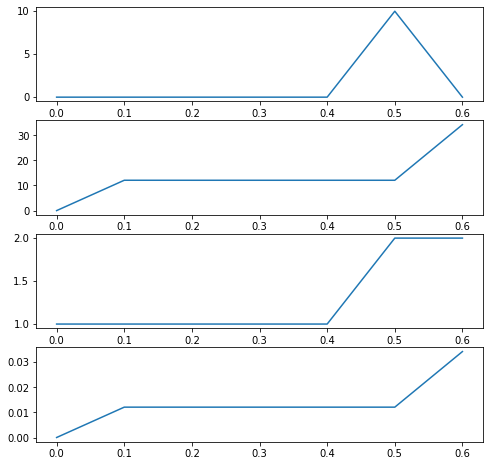

In [218]:
dur = 0.6

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,5] += 10.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.rates_exc[:,:]
print(target)

fig, axes = plt.subplots(4, figsize=(8, 8))
axes[0].plot(a.t, control1[0,0,:])
axes[1].plot(a.t, a.state["rates_exc"][0,:])
axes[2].plot(a.t, a.state["mufe"][0,:])
axes[3].plot(a.t, a.state["sigmae_f"][0,:])

In [221]:
max_cntrl = 100. * 5.
start_step = 100.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 20

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  24.490137597562224
phi =  [[[ 1.06229542e-20 -3.76636012e-17  1.34815718e-13 -4.82567476e-10
    1.72733101e-06 -6.18291235e-03  2.21314878e+01]
  [ 2.86946366e+01  2.86946366e+01  2.86946366e+01  2.86946343e+01
    2.87026531e+01  0.00000000e+00  0.00000000e+00]
  [ 1.06229542e-17 -3.76636012e-14  1.34815718e-10 -4.82567476e-07
    1.72733101e-03 -6.18291235e+00  0.00000000e+00]]]
RUN  1 , total integrated cost =  16.22444838121136
phi =  [[[-1.26006305e-07  4.46754372e-04 -1.59914372e+00 -3.40392913e+00
   -5.43561116e+00 -7.72377702e+00  1.44123468e+01]
  [-4.13777048e+00 -1.79442361e+00  3.82820006e+00  1.39220620e+01
    2.99988775e+01  0.00000000e+00  0.00000000e+00]
  [-1.26006305e-04  4.46754372e-01  9.49758451e-01  1.51446879e+00
    2.14853523e+00 -4.00185900e+00  0.00000000e+00]]]
RUN  2 , total integrated cost =  15.700245653937952
phi =  [[[-1.13349361e-07  4.01879276e-04 -1.43851468e+00 -3.28891134e+00
   -5.88830795e+00 -

[[[0.33829928 0.33820293 0.72081743 1.95911649 5.94943082 0.88048596
   0.        ]]]


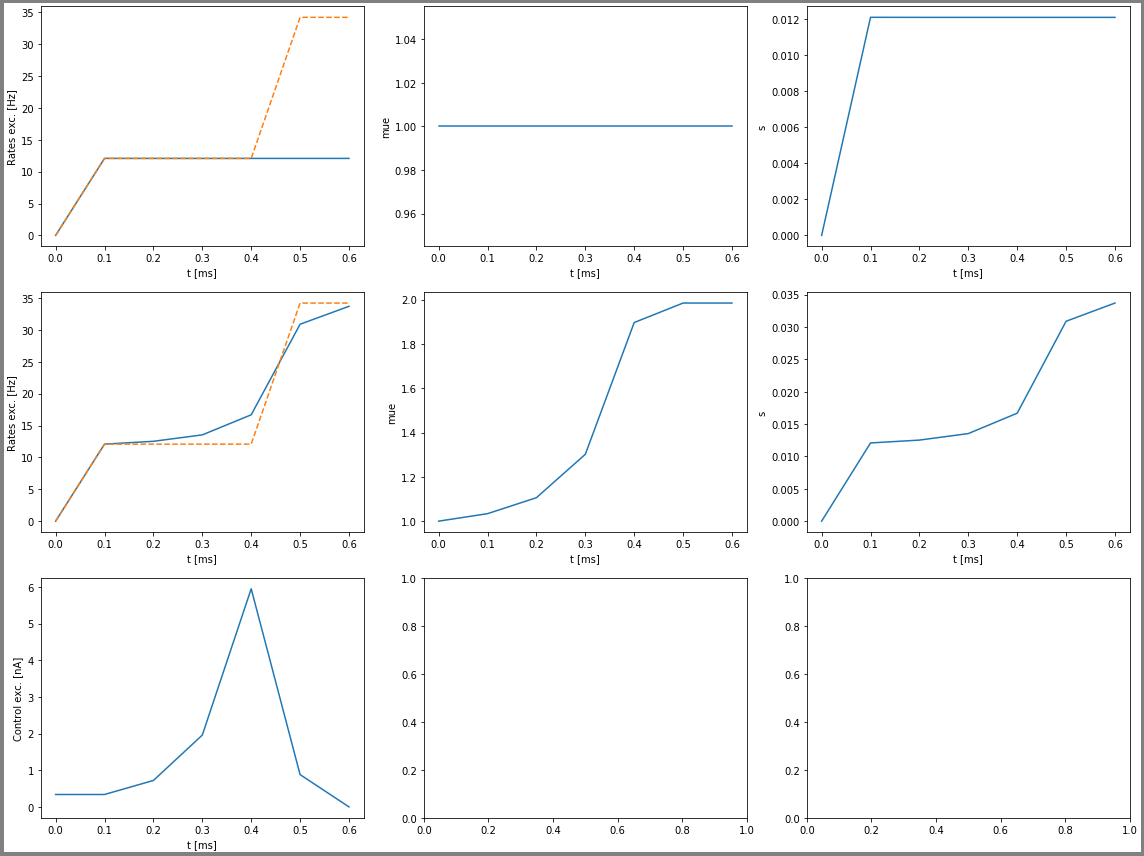

In [210]:
#1.5130136397445144
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [211]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 40

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  48.97815738194395
RUN  1 , total integrated cost:  22.518653789868374
RUN  2 , total integrated cost:  11.064755468292077
RUN  3 , total integrated cost:  7.718701004002773
RUN  4 , total integrated cost:  6.59853788533844
RUN  5 , total integrated cost:  6.203866455009779
RUN  6 , total integrated cost:  6.055794887408343
RUN  7 , total integrated cost:  5.991024894323904
RUN  8 , total integrated cost:  5.95320270938088
RUN  9 , total integrated cost:  5.924085077813922
RUN  10 , total integrated cost:  5.899126033152768
RUN  11 , total integrated cost:  5.87758608623681
RUN  12 , total integrated cost:  5.8597835522226225
RUN  13 , total integrated cost:  5.845808423341616
RUN  14 , total integrated cost:  5.835329663722148
RUN  15 , total integrated cost:  5.827773515401029
change helped, counter =  1
RUN  16 , total integrated cost:  5.82256072036761
RUN  17 , total integrated cost:  5.819094378695142
RUN  18 , total integrated cost:

[[[0.33829928 0.39341821 0.74215423 1.8809983  5.95844535 0.86756135
   0.        ]]]


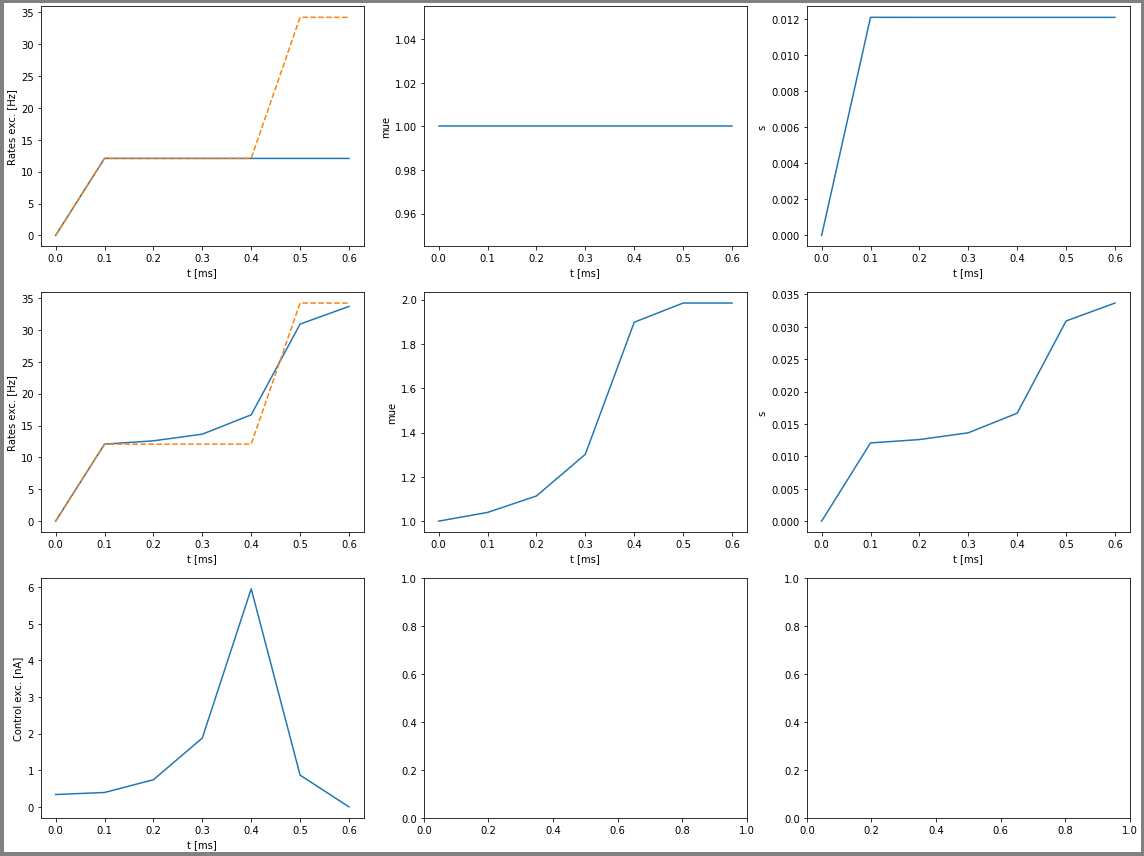

In [212]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

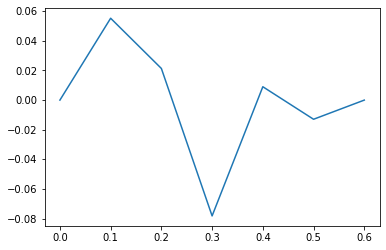

In [213]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


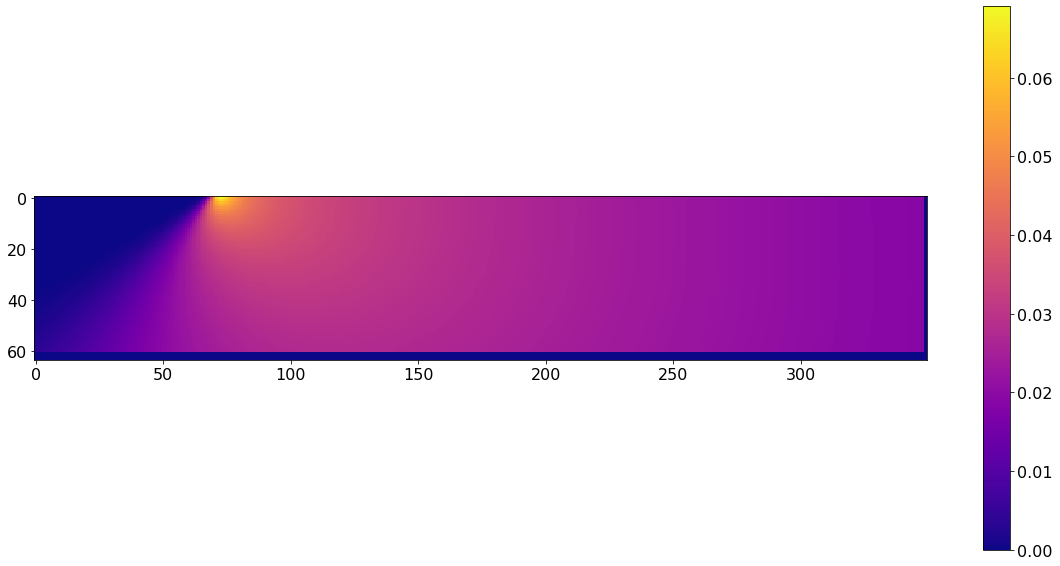

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


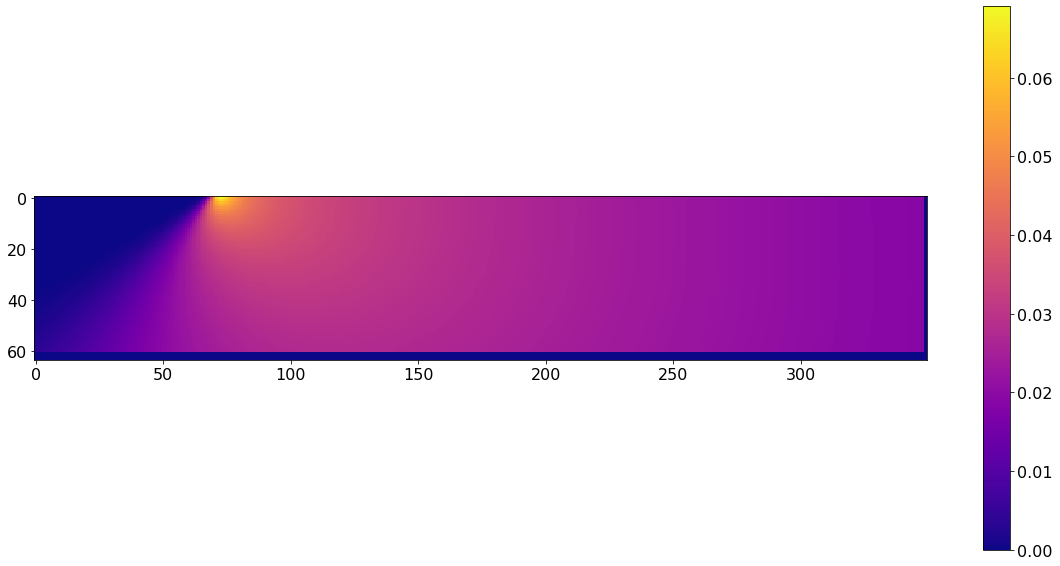

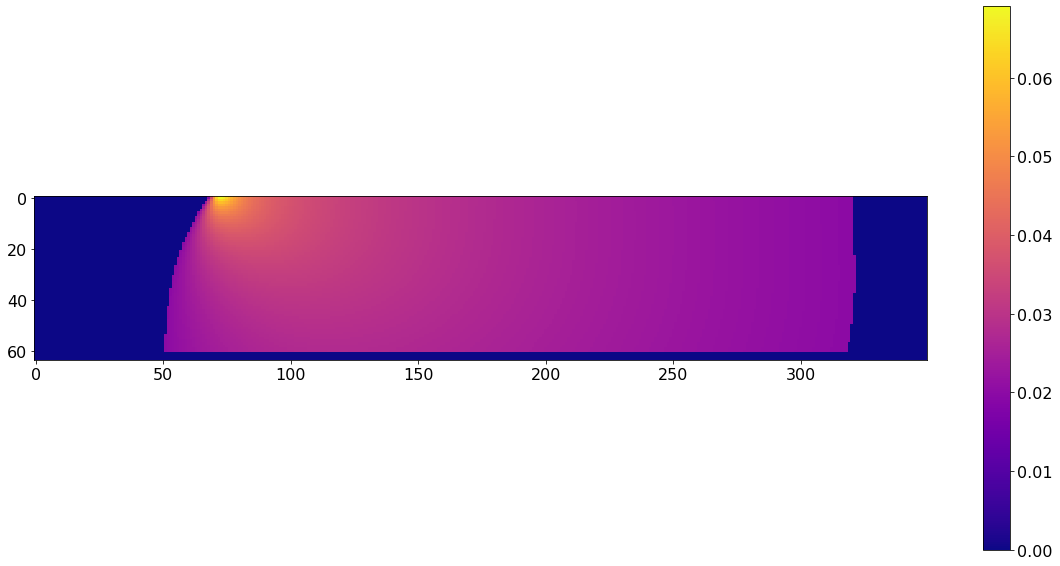

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()